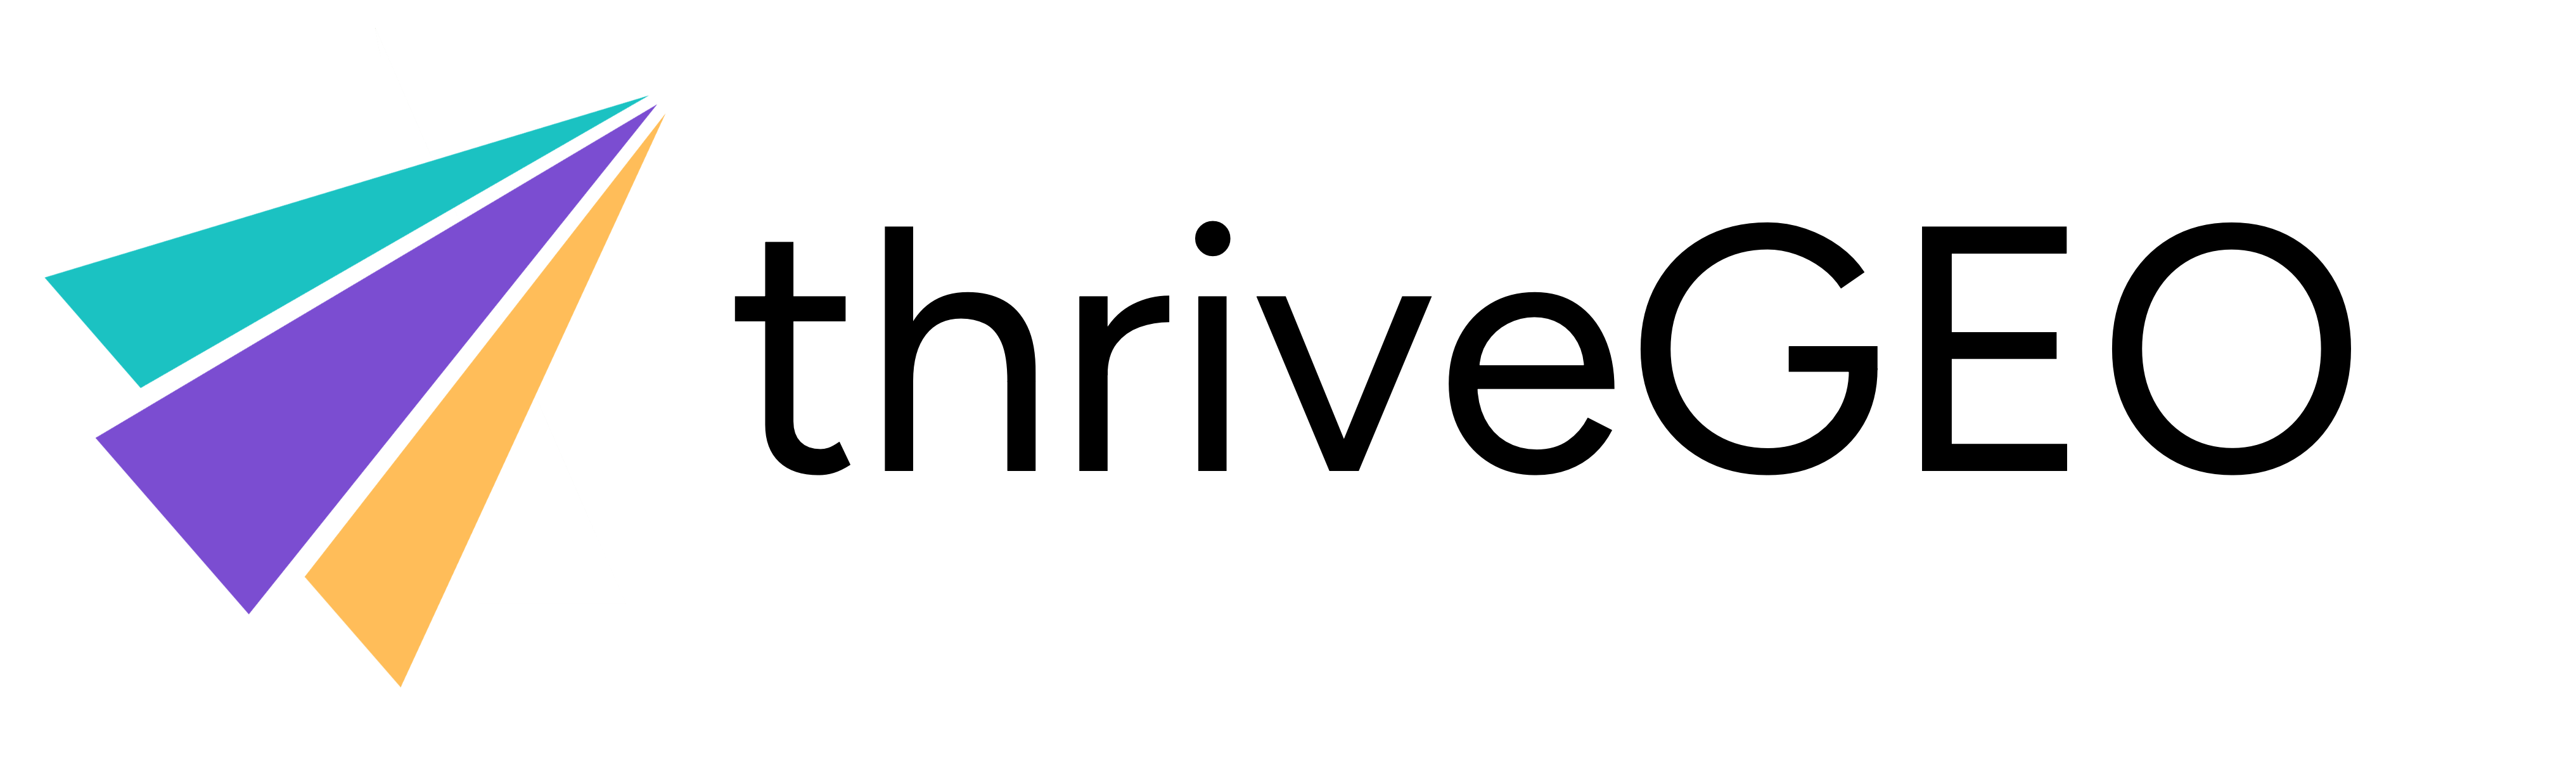

### CNG 101 - Module 4 Practical Part 1 - Solutions

# 🚀 Discover Dask

### Introduction

This tutorial provides a general introduction to Dask and shows the fundamental principles of Dask with the example of Dask Arrays. The same principles apply for Dask Dataframes.


### By the end of this tutorial, you will be able to...
* **Initiate a local Dask cluster**, and
* **Perform parallel operations** on multi-dimensional arrays with the help of Dask

### Notebook Outline
* [Introduction to Dask](#dask_intro)
* [Exercise 1: Processing satellite data with Dask](#exercise1) 

<hr>

**Import required libraries**

In [3]:
!conda install graphviz -y

Retrieving notices: done
Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.11.1
    latest version: 26.1.0

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /opt/conda

  added / updated specs:
    - graphviz


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    adwaita-icon-theme-49.0    |           unix_0         617 KB  conda-forge
    at-spi2-atk-2.38.0         |       h0630a04_3         332 KB  conda-forge
    at-spi2-core-2.40.3        |       h0630a04_0         643 KB  conda-forge
    atk-1.0-2.38.0             |       h04ea711_2         348 KB  conda-forge
    cairo-1.18.4               |       he90730b_1         966 KB  conda-forge
    dbus-1.16.2                |       h24cb091_1         437 KB  conda-forge
   

In [2]:
from dask.distributed import Client
import dask.base
import dask.array as da
import numpy as np
import xarray
#import graphviz

<hr>

## <a id='dask_intro'>Introduction to Dask </a>

### Start a Dask Client

The first step is to initiate a local cluster and attach a Dask Client to it. Open the Dask pane on the left side and create a new cluster. As Dask Client address, copy paste the Scheduler address into the brackets.



<div class="alert alert-block alert-warning"> 
<b>Questions:</b>
<br>
- ➡️ 1. What information do you get from the Client? <br>
- ➡️ 2. How many workers are initiated?<br>
</div>

In [4]:
#client = Client('SCHEDULER_ADDRESS')
client = Client('tcp://127.0.0.1:41189')
client

<Client: 'tcp://127.0.0.1:41189' processes=4 threads=16, memory=125.79 GiB>

Let us start by defining a simple numpy array.

In [5]:
narr = np.array([
        [ 11,  22,  33,  44],
        [ 55,  66,  77,  88],
        [ 99, 100, 111, 122],
        [133, 144, 155, 166]
        ])
narr

array([[ 11,  22,  33,  44],
       [ 55,  66,  77,  88],
       [ 99, 100, 111, 122],
       [133, 144, 155, 166]])

Now, we can convert the numpy array into a Dask array.

In [6]:
daskarr = da.from_array(narr, chunks=(2,2))
daskarr

dask.array<array, shape=(4, 4), dtype=int64, chunksize=(2, 2), chunktype=numpy.ndarray>

<div class="alert alert-block alert-warning"> 
<b>Questions:</b>
<br>
- ➡️ 1. How does the Dask array differ compared to the numpy array? <br>
</div>

### Dask TaskGraph

The Dask Task Graph serves as a blueprint for executing the computations. The Task Graph defines the (1) relationships between tasks, and (2) the order in which they will be executed. In a task graph each node in the graph represents a task and lines represent the dependencies/relationships between tasks.

You can visualize the low-level task graph using the `.visualize()` method. Let us now visualise the TaskGraph is we would like to calculate the sum of our Dask Array created before.

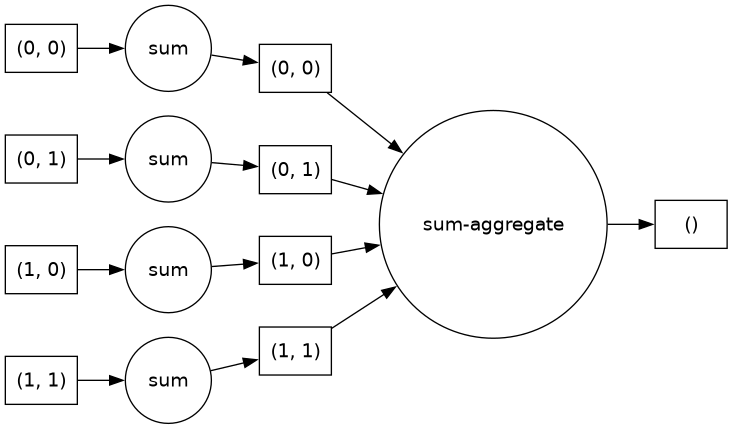

In [11]:
daskarr.sum().visualize(rankdir='LR')

For bigger computations, task graphs can become quite big. With `dask.visualize()`, you can get a more concise representation of the graph.

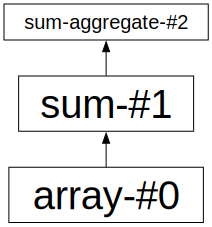

In [12]:
daskarr.sum().dask.visualize()

### Chunking

Let us create another array and convert it into a Dask Array.

In [7]:
shape = (10000,12000)

ones_np = np.ones(shape)
ones_da = da.ones(shape)
ones_da

dask.array<ones_like, shape=(10000, 12000), dtype=float64, chunksize=(4096, 4096), chunktype=numpy.ndarray>

<div class="alert alert-block alert-warning"> 
<b>Questions:</b>
<br>
- ➡️ 1. What is the default chunking size? <br>
- ➡️ 2. How big are the chunking sizes in bytes compared to the total array? <br>
</div>

You can also define how the array shall be chunked, by setting the keyword argument `chunks`. 
There are several ways to define chunks. For example:
* A `uniform dimension` size like 1000, meaning chunks of size 1000 in each dimension.
* A `uniform chunk shape` like (1000, 2000, 3000), meaning chunks of size 1000 in the first axis, 2000 in the second axis, and 3000 in the third.
* Fully `explicit sizes of all blocks for all dimensions`, like ((1000, 1000, 500), (400, 400), (5, 5, 5, 5, 5))
* A `dictionary specifying chunk size per dimension` like {0: 1000, 1: 2000, 2: 3000}.

Let us recreate the array from above and define a specific chunk shape.

In [8]:
chunks = (5000, 4000) # defines the size of the chunks
ones_da = da.ones(shape, chunks=chunks)
ones_da

dask.array<ones_like, shape=(10000, 12000), dtype=float64, chunksize=(5000, 4000), chunktype=numpy.ndarray>

### Comparison of computing times

Now, let us compare the difference in computing times. Let us create the mean of the numpy array.

In [9]:
%%time
ones_np.mean()

CPU times: user 204 ms, sys: 23 μs, total: 204 ms
Wall time: 202 ms


np.float64(1.0)

Averaging over the Dask array is much faster, compared to the operation on the numpy array. 

In [10]:
%%time
mean_of_ones_da = ones_da.mean()

CPU times: user 5.58 ms, sys: 244 μs, total: 5.82 ms
Wall time: 5.55 ms


<div class="alert alert-block alert-warning"> 
<b>Questions:</b>
<br>
- ➡️ 1. Why is the computation on the Dask array faster? <br>
</div>

In [12]:
print(f'Dask is quicker, because the key feature is lazy loading')

Dask is quicker, because the key feature is lazy loading


Remember, Dask Arrays are lazy. The actual computation did not happen yet. Only the task graph was created. You initiate the actual computation by running the `compute()` function.

In [14]:
%%time
mean_of_ones_da.compute()

CPU times: user 10.4 ms, sys: 1.57 ms, total: 12 ms
Wall time: 73.5 ms


np.float64(1.0)

<div class="alert alert-block alert-warning"> 
<b>Questions:</b>
<br>
- ➡️ 1. What do you see in Dask dashboard when you execute the computation? <br>
</div>

The `compute()` method converts a Dask Array into a numpy array, what you can verify by checking the type.

In [15]:
type (ones_da.compute())

numpy.ndarray

Let us visualize the Task Graph of an averaging operation.

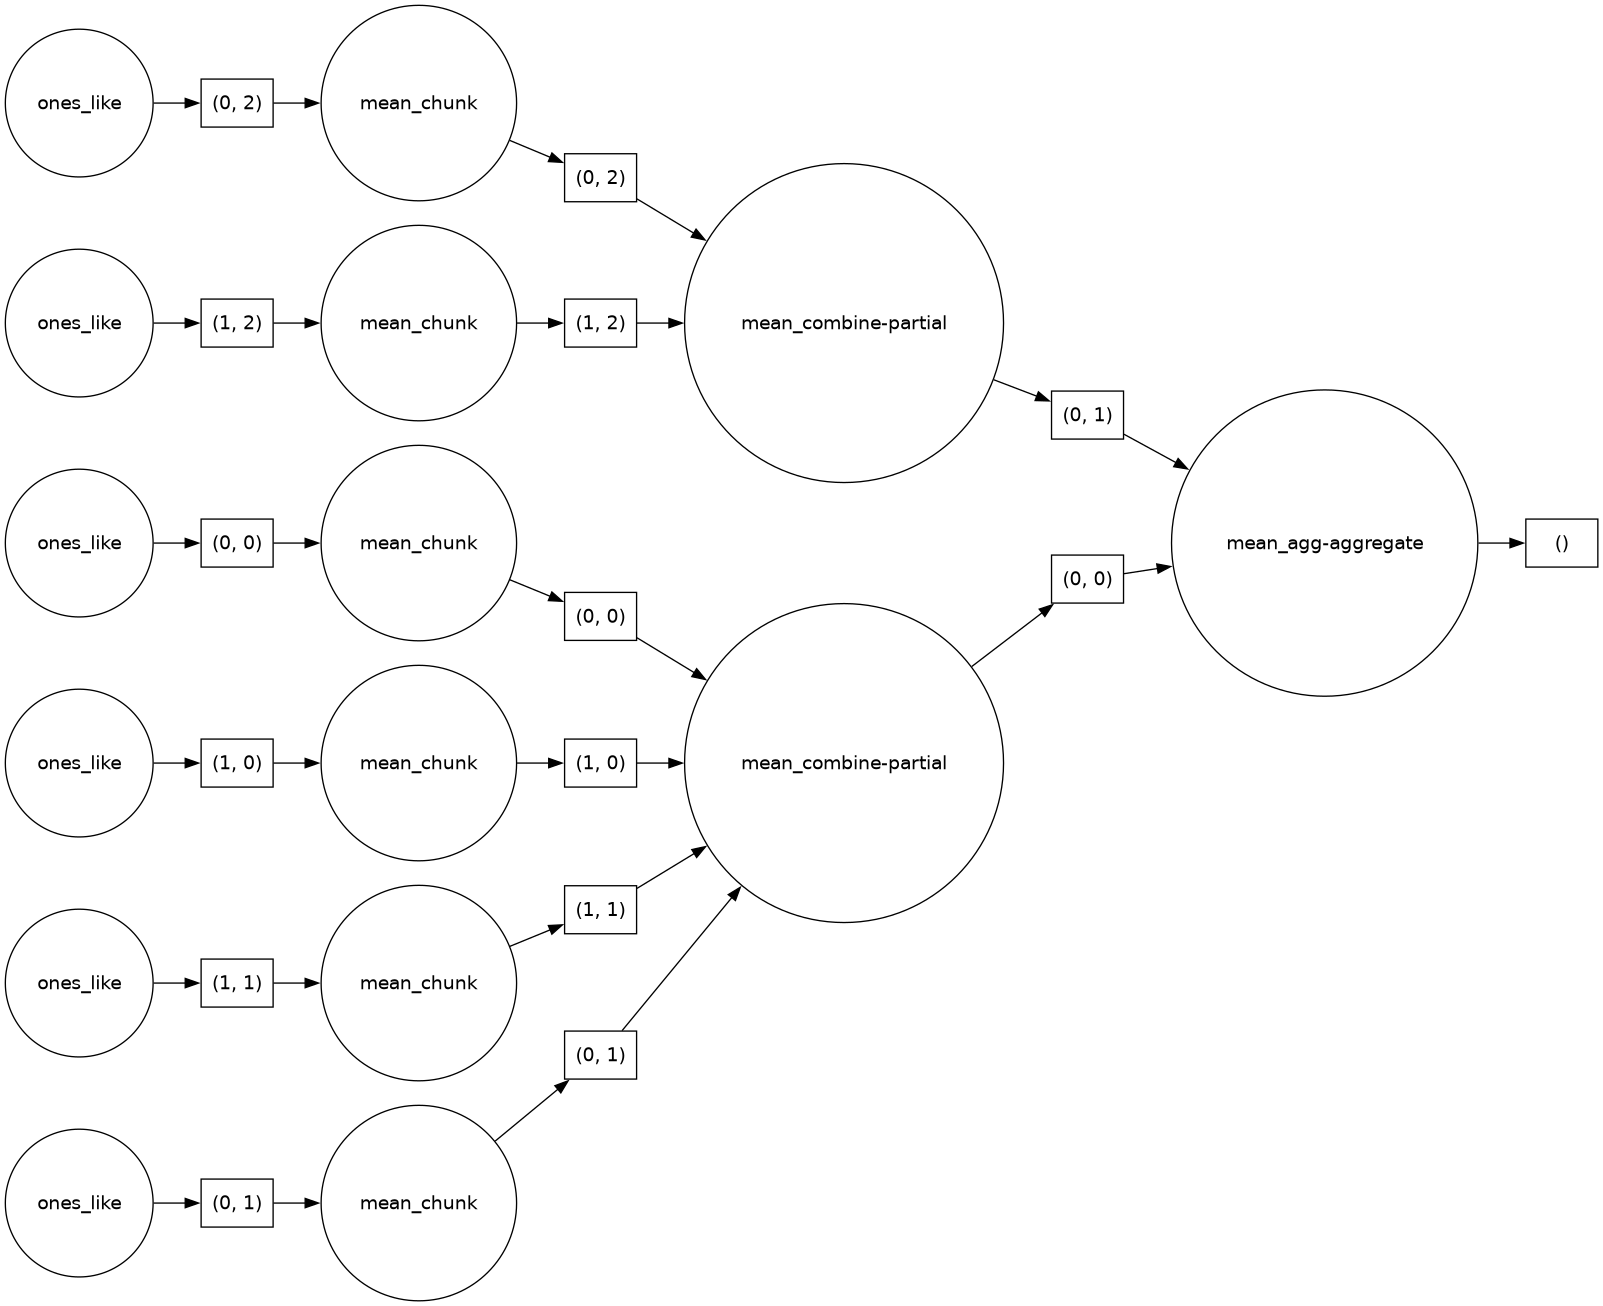

In [19]:
mean_of_ones_da = ones_da.mean()
mean_of_ones_da.visualize(rankdir="LR")

### Comparison of array sizes

Let us define a function that return the size of an array.

In [16]:
import sys

# Define function to display variable size in MiB
def var_size(in_var):
    result = sys.getsizeof(in_var) / 1024/1024
    return (result)

Below, you compare the file size of a numpy array and the Dask array.

In [17]:
print("Shape of the numpy array : ", ones_np.shape) 
print("Shape of the dask array  : ", ones_da.shape) 

# memory size of numpy array in MiB
print(f"Memory size of numpy array in MB : {var_size(ones_np):.2f} MiB")
# memory size of dask array in MiB
print(f"Memory size of dask array in MB  : {var_size(ones_da):.2f} MiB")

Shape of the numpy array :  (10000, 12000)
Shape of the dask array  :  (10000, 12000)
Memory size of numpy array in MB : 915.53 MiB
Memory size of dask array in MB  : 0.00 MiB


<div class="alert alert-block alert-warning"> 
<b>Questions:</b>
<br>
- ➡️ 1. Why is the size of the Dask Array zero? <br>
</div>

In [19]:
print('Because you need to add the nbytes() function')

Because you need to add the nbytes() function


The Dask Array function `nbytes()` allows you to retrieve the size of the Dask Array.

In [20]:
print("Size of Dask dataset:  {:.2f} MiB".format(ones_da.nbytes / 1024/1024))

Size of Dask dataset:  915.53 MiB


### Computations on larger data

Let us create a large array that has ~ 6 GBs. Creating it as a numpy array will most likely not fit into your local machine.

In [21]:
big_shape = (2000, 200, 2000)

# -- this will make a big numpy array that might not fit on your machine
#big_np = np.ones(big_shape)

But creating it as a Dask Array is possible, because of the lazy loading.

In [23]:
big_da = da.ones(big_shape)
big_da

dask.array<ones_like, shape=(2000, 200, 2000), dtype=float64, chunksize=(289, 200, 289), chunktype=numpy.ndarray>

You can see above the size of the created array: ~ 6GB.

Let us do a more complicated calculation. Remember, in order to initiate the compute, you have to call the function `compute()`.

In [24]:
%%time

z_da = (big_da + big_da.T)[::2,:].mean(axis=2)
result = z_da.compute()

CPU times: user 28.1 ms, sys: 5.32 ms, total: 33.4 ms
Wall time: 910 ms


Now, let us rechunk the array and have instead of 49 chunks 6400 chunks.

In [25]:
new_chunk_shape = (50,50,50)
rechunked_big_da = big_da.rechunk(new_chunk_shape)
rechunked_big_da

dask.array<rechunk-merge, shape=(2000, 200, 2000), dtype=float64, chunksize=(50, 50, 50), chunktype=numpy.ndarray>

Now, repeat the same computation over the rechunked array. What do you observe?

In [26]:
%%time
z_da_rechunked = (rechunked_big_da + rechunked_big_da.T)[::2,:].mean(axis=2)

result = z_da_rechunked.compute()

CPU times: user 474 ms, sys: 43 ms, total: 517 ms
Wall time: 38.6 s


<div class="alert alert-block alert-warning"> 
<b>Questions:</b>
<br>
- ➡️ 1. Compare the computation times with fewer chunks and more chunks. What do you observe? <br>
</div>

Note: it is not recommended to visualise the detailed task graph of big arrays. You could try the concise view instead.

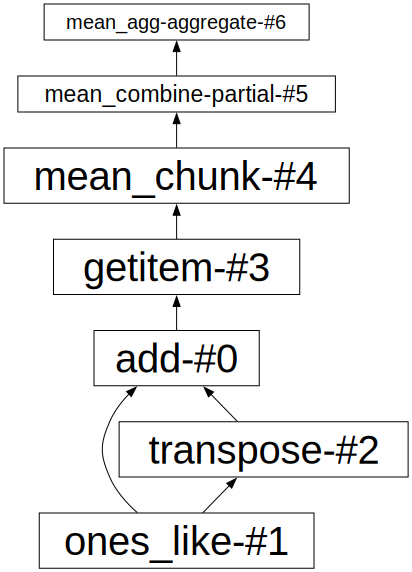

In [22]:
#z_da.visualize()
z_da.dask.visualize()

<hr>

## <a id='exercise1'></a>Exercise 1: Processing satellite data with Dask

<div class="alert alert-block alert-warning"> 
<b>Instructions:</b>
<br>
- ➡️ 1. Repeat an example given in 05_Chunking_Exercises notebook: initiate a Dask cluster and execute the processing examples.<br>
- ➡️ 2. How do the processing times differ? Without Dask and with Dask?
</div>

In [1]:
from pystac_client import Client, CollectionClient
from pystac import Collection, MediaType
import datetime
import xarray as xr
import rioxarray
import rasterio
import planetary_computer as pc
from rasterio.crs import CRS
import adlfs

In [2]:
# Add your code solution here

# Without Dask

# Connect to catalogue
pc_stac_api_root_endpoint = "https://planetarycomputer.microsoft.com/api/stac/v1" #root starting point
pc_catalog = Client.open(url=pc_stac_api_root_endpoint, modifier=pc.sign_inplace) # calls the selected url
#pc_catalog

# Search catalogue
search = pc_catalog.search(
    collections=["era5-pds"], datetime="2000-01/2000-06", query={"era5:kind": {"eq": "an"}}
)
items_era = search.item_collection()
signed_items = [pc.sign(item) for item in items_era]
#items_era

asset_key = 'air_temperature_at_2_metres'

# Generate a data set from the found assets for the month of May:
datasets = []
for item in signed_items:
    asset = item.assets[asset_key]
      
    # Open each day individually
    ds = xr.open_dataset(
        asset.href, 
        **asset.extra_fields["xarray:open_kwargs"]
    )
    datasets.append(ds)

# Concatenate them along the time dimension
pp_dt = xr.concat(datasets, dim="time")

# Sorting the data through the time dimension:
pp_dt = pp_dt.sortby("time")

# Conversion step
new_lon = ((pp_dt.lon + 180) % 360) - 180
pp_da = pp_dt.assign_coords(lon=new_lon).sortby("lon")

# Define data array as a variable
full_array = pp_da

# Apply chunking
loaf_bread_space_opt_chunks = full_array['air_temperature_at_2_metres'].chunk({"lat": -1, "lon": -1})
#loaf_bread_space_opt_chunks



UsageError: Line magic function `%%time` not found.


In [10]:
%%time
avg_day_nc = loaf_bread_space_opt_chunks.mean('time').compute()
avg_day_nc

CPU times: user 250 ms, sys: 24.6 ms, total: 274 ms
Wall time: 1min 34s


<xarray.DataArray 'air_temperature_at_2_metres' (lat: 721, lon: 1440)> Size: 4MB
array([[256.5069 , 256.5069 , 256.5069 , ..., 256.5069 , 256.5069 ,
        256.5069 ],
       [256.39777, 256.39755, 256.39734, ..., 256.39874, 256.39847,
        256.398  ],
       [256.35263, 256.35226, 256.3518 , ..., 256.35382, 256.35336,
        256.353  ],
       ...,
       [225.71059, 225.71362, 225.71684, ..., 225.70117, 225.70395,
        225.70735],
       [225.4689 , 225.47067, 225.4724 , ..., 225.46407, 225.46579,
        225.46732],
       [225.44098, 225.44098, 225.44098, ..., 225.44098, 225.44098,
        225.44098]], shape=(721, 1440), dtype=float32)
Coordinates:
  * lat      (lat) float32 3kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon      (lon) float32 6kB -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
Attributes:
    long_name:       2 metre temperature
    nameCDM:         2_metre_temperature_surface
    nameECMWF:       2 metre temperature
    product_type:    analysis
    shortNameECMWF:  2t
    standard_name:   air_temperature
    units:           K

In [5]:
from dask.distributed import Client
import dask.base
import dask.array as da
import numpy as np
import xarray
#import graphviz


In [7]:
# With Dask
client = Client('tcp://127.0.0.1:38711')
client


<Client: 'tcp://127.0.0.1:38711' processes=4 threads=16, memory=125.79 GiB>

In [11]:
daskarr = da.from_array(loaf_bread_space_opt_chunks)
daskarr

dask.array<rechunk-merge, shape=(4368, 721, 1440), dtype=float32, chunksize=(364, 721, 1440), chunktype=numpy.ndarray>

In [12]:
%%time
with_dask = daskarr.mean('time').compute()
with_dask

CPU times: user 267 μs, sys: 0 ns, total: 267 μs
Wall time: 279 μs


TypeError: Axis value must be an integer, got time

<hr>

&copy; 2026 thriveGEO GmbH
